In [61]:
import os

import ffmpeg
import kagglehub
import pandas as pd
import torch
import torchaudio
from datasets import load_dataset
import numpy as np
%matplotlib inline

from TTS import XttsConfig
from TTS.tts.models.xtts import Xtts

In [62]:
def convert_mp3_to_wav(mp3_file_path, wav_output_path):
    stream = ffmpeg.input(mp3_file_path)
    stream = ffmpeg.output(stream, wav_output_path, acodec='pcm_s16le', ac=1, ar='22050')
    ffmpeg.run(stream, overwrite_output=True)


device = "cuda" if torch.cuda.is_available() else "cpu"

In [70]:
# Load dataset
df = load_dataset("ajd12342/paraspeechcaps", split="train_scaled").to_pandas()

print("Unique Genders:", df["gender"].unique())
print("Unique Speeds:", df["speaking_rate"].unique())
print("Unique Pitches:", df["pitch"].unique())

Unique Genders: ['female' 'male']
Unique Speeds: ['measured speed' 'fast speed' 'slow speed']
Unique Pitches: ['high-pitched' 'medium-pitched' 'low-pitched']


In [68]:
# Function to compute balance score for each accent
def compute_balance_score(df):
    accent_scores = []
    
    for accent, group in df.groupby("accent"):
        unique_genders = group["gender"].nunique()
        unique_speeds = group["speaking_rate"].nunique()
        unique_pitches = group["pitch"].nunique()

        # Balance Score: More unique values = better balance
        score = unique_genders + unique_speeds + unique_pitches
        
        accent_scores.append((accent, unique_genders, unique_speeds, unique_pitches, score))

    # Convert to DataFrame
    score_df = pd.DataFrame(accent_scores, columns=["accent", "genders", "speeds", "pitches", "score"])
    
    return score_df.sort_values("score", ascending=False)

# Compute scores
score_df = compute_balance_score(df)

# Display top 10 accents with the best balance
print("Top 10 accents by balance score:")
print(score_df.head(15))

# We will select Indian, French, German, as those are three well balanced accents that we can
# generate using XTTS's language option.


Top 10 accents by balance score:
         accent  genders  speeds  pitches  score
0      american        2       3        3      8
7      canadian        2       3        3      8
27     scottish        2       3        3      8
19        irish        2       3        3      8
1    australian        2       3        3      8
14       french        2       3        3      8
12      english        2       3        3      8
29        welsh        2       3        3      8
4       british        2       3        3      8
15       german        2       3        2      7
17       indian        2       3        2      7
23  new zealand        1       3        3      7
20      italian        1       3        3      7
25   portuguese        1       3        2      6
21     japanese        1       3        2      6


In [78]:
from datasets import load_dataset

# We will select Indian, French, German, as those are three well balanced accents that we can
# generate using XTTS's language option.
accents = ["indian", "french", "german"]
df_filtered = df[df["accent"].isin(accents)]

num_samples_per_group = min(
    df_filtered.groupby(["accent", "gender", "speaking_rate", "pitch"]).size().min(), 
    100  # Adjust this number as needed
)

df_balanced = (
    df_filtered.groupby(["accent", "gender", "speaking_rate", "pitch"])
    .apply(lambda x: x.sample(n=num_samples_per_group, random_state=42) if len(x) >= num_samples_per_group else x)
    .reset_index(drop=True)
)

print("Final dataset shape:", df_balanced.shape)

Final dataset shape: (66, 19)


/var/folders/7_/8dpjh7yj6jxfyznn_glnt44w0000gn/T/ipykernel_77167/19913316.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=num_samples_per_group, random_state=42) if len(x) >= num_samples_per_group else x)


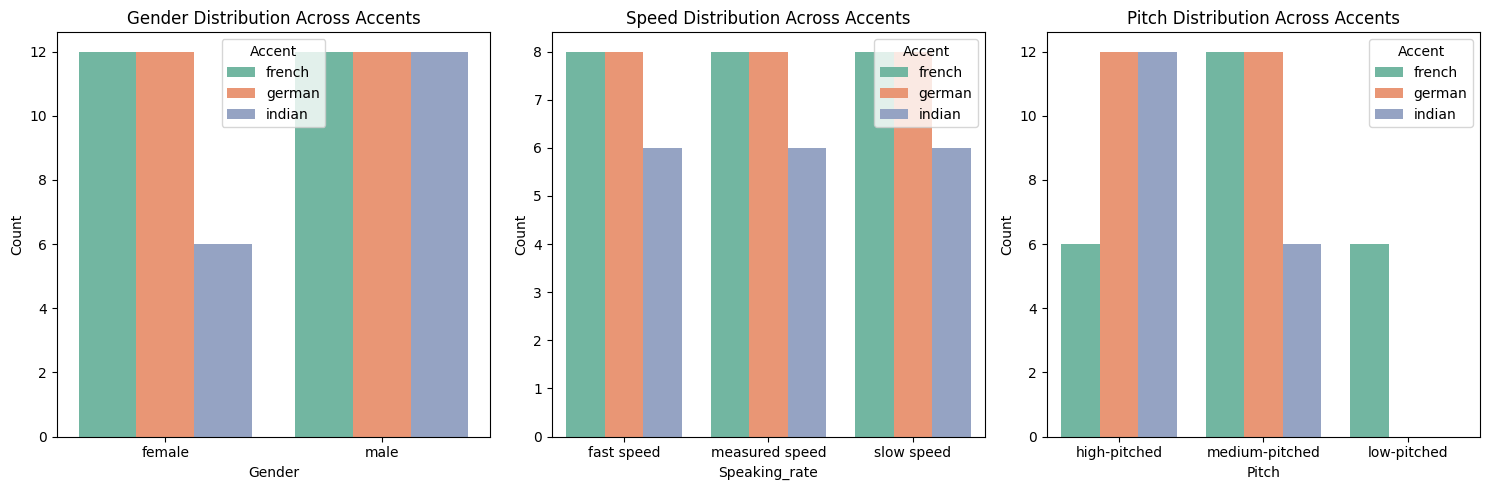

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from IPython.display import display

# Ensure Matplotlib displays inline
%matplotlib inline

def plot_distribution_side_by_side(df, columns, titles):
    fig, axes = plt.subplots(1, len(columns), figsize=(15, 5))  # Adjust figure size
    for ax, column, title in zip(axes, columns, titles):
        sns.countplot(data=df, x=column, hue="accent", palette="Set2", ax=ax)
        ax.set_title(title)
        ax.set_xlabel(column.capitalize())
        ax.set_ylabel("Count")
        ax.legend(title="Accent")
        #ax.set_xticklabels(ax.get_xticklabels(), rotation=30)
    
    plt.tight_layout()  # Ensures proper spacing
    plt.show()

# List of columns and corresponding titles
columns = ["gender", "speaking_rate", "pitch"]
titles = ["Gender Distribution Across Accents", "Speed Distribution Across Accents", "Pitch Distribution Across Accents"]

# Generate and display distribution plots side by side
plot_distribution_side_by_side(df_balanced, columns, titles)


In [5]:
# From Mozilla Common Voice, sample a few acccents and convert to wav.
def sample_accents():
    # Download latest version
    common_voice_path = kagglehub.dataset_download("mozillaorg/common-voice")
    common_voice_file = "cv-valid-dev"

    print("Path to Common Voice dataset files:", common_voice_path)

    df = pd.read_csv(common_voice_path + f"/{common_voice_file}.csv", sep=',')
    good_samples = df[(df['up_votes'] >= 2) & (df['down_votes'] == 0) & (df['accent'].notna())]

    # Check how many accents are available and their distribution:
    print(good_samples['accent'].value_counts())

    selected_accents = ['indian', 'australia', 'african']
    accented_samples = good_samples[good_samples['accent'].isin(selected_accents)]
    accented_samples = accented_samples.groupby('accent').sample(n=5, random_state=42)

    print(accented_samples)

    # Set your output directory
    output_dir = common_voice_path + f"/{common_voice_file}/wav_out"
    os.makedirs(output_dir, exist_ok=True)  # ensure the folder exists

    output_paths = {}
    for idx, row in accented_samples.iterrows():
        accent = row['accent']
        filename = row['filename']

        os.makedirs(output_dir + f"/{accent}/{common_voice_file}", exist_ok=True)  # ensure the folder exists
        input_path = common_voice_path + f"/{common_voice_file}/{filename}"
        output_path = output_dir + f"/{accent}/{filename[:-4]}.wav"

        convert_mp3_to_wav(input_path, output_path)
        accent_list = output_paths.setdefault(accent, [])
        accent_list.append(output_path)
    return output_paths

In [6]:
def synthesize(output_paths, sentences):
    config = XttsConfig()
    config.load_json("config/xtts/config.json")
    model = Xtts.init_from_config(config)
    model.load_checkpoint(config, checkpoint_dir="config/xtts/", use_deepspeed=False)
    model.cpu()

    for accent in output_paths:
        paths = output_paths[accent]
        for idx, path in enumerate(paths):
            print("Computing speaker latents...")
            gpt_cond_latent, speaker_embedding = model.get_conditioning_latents(audio_path=[path])
            # gpt_cond_latent, speaker_embedding = model.speaker_manager.speakers[speaker].values()

            print(f"Inference...")

            for sentence_idx, sentence in enumerate(sentences):
                out = model.inference(
                    sentence,
                    "en",
                    gpt_cond_latent,
                    speaker_embedding,
                    temperature=0.2,  # Add custom parameters here
                )
                os.makedirs(f"out/{accent}", exist_ok=True)  # ensure the folder exis
                torchaudio.save(f"out/{accent}/{idx}_{sentence_idx}_xttsgen.wav", torch.tensor(out["wav"]).unsqueeze(0), 24000)

In [7]:
output_paths = sample_accents()
output_paths

Path to Common Voice dataset files: /Users/ethan/.cache/kagglehub/datasets/mozillaorg/common-voice/versions/2
accent
us                311
england           139
australia          48
canada             45
indian             40
african            14
scotland           12
ireland             9
newzealand          9
philippines         4
bermuda             3
malaysia            2
southatlandtic      1
wales               1
Name: count, dtype: int64
                            filename  \
3345  cv-valid-dev/sample-003345.mp3   
3771  cv-valid-dev/sample-003771.mp3   
328   cv-valid-dev/sample-000328.mp3   
3867  cv-valid-dev/sample-003867.mp3   
2965  cv-valid-dev/sample-002965.mp3   
1126  cv-valid-dev/sample-001126.mp3   
838   cv-valid-dev/sample-000838.mp3   
321   cv-valid-dev/sample-000321.mp3   
3764  cv-valid-dev/sample-003764.mp3   
699   cv-valid-dev/sample-000699.mp3   
2842  cv-valid-dev/sample-002842.mp3   
1809  cv-valid-dev/sample-001809.mp3   
198   cv-valid-dev/sample-000

ffmpeg version 6.1.1 Copyright (c) 2000-2023 the FFmpeg developers
  built with clang version 14.0.6
  configuration: --prefix=/opt/anaconda3/envs/coqui-tts --cc=arm64-apple-darwin20.0.0-clang --ar=arm64-apple-darwin20.0.0-ar --nm=arm64-apple-darwin20.0.0-nm --ranlib=arm64-apple-darwin20.0.0-ranlib --strip=arm64-apple-darwin20.0.0-strip --disable-doc --enable-swresample --enable-swscale --enable-openssl --enable-libxml2 --enable-libtheora --enable-demuxer=dash --enable-postproc --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libdav1d --enable-zlib --enable-libaom --enable-pic --enable-shared --disable-static --disable-gpl --enable-version3 --disable-sdl2 --enable-libopenh264 --enable-libopus --enable-libmp3lame --enable-libopenjpeg --enable-libvorbis --enable-pthreads --enable-libtesseract --enable-libvpx --enable-librsvg
  libavutil      58. 29.100 / 58. 29.100
  libavcodec     60. 31.102 / 60. 31.102
  libavformat    60. 16.100 / 60

{'african': ['/Users/ethan/.cache/kagglehub/datasets/mozillaorg/common-voice/versions/2/cv-valid-dev/wav_out/african/cv-valid-dev/sample-003345.wav',
  '/Users/ethan/.cache/kagglehub/datasets/mozillaorg/common-voice/versions/2/cv-valid-dev/wav_out/african/cv-valid-dev/sample-003771.wav',
  '/Users/ethan/.cache/kagglehub/datasets/mozillaorg/common-voice/versions/2/cv-valid-dev/wav_out/african/cv-valid-dev/sample-000328.wav',
  '/Users/ethan/.cache/kagglehub/datasets/mozillaorg/common-voice/versions/2/cv-valid-dev/wav_out/african/cv-valid-dev/sample-003867.wav',
  '/Users/ethan/.cache/kagglehub/datasets/mozillaorg/common-voice/versions/2/cv-valid-dev/wav_out/african/cv-valid-dev/sample-002965.wav'],
 'australia': ['/Users/ethan/.cache/kagglehub/datasets/mozillaorg/common-voice/versions/2/cv-valid-dev/wav_out/australia/cv-valid-dev/sample-001126.wav',
  '/Users/ethan/.cache/kagglehub/datasets/mozillaorg/common-voice/versions/2/cv-valid-dev/wav_out/australia/cv-valid-dev/sample-000838.wav'

In [8]:


sentences = [
    "The quick brown fox jumps over the lazy dog.",
    "In 2023, Maria traveled from Berlin to New York City.",
    "The chef quickly judged the exquisite flavor of the sizzling dishes.",
    "Christopher regularly visits Melbourne every Thursday.",
    "The sheep grazing quietly judged the exquisite flavor of the sizzling dishes."
]

# Now, for each speaker embedding, generate 5 different sentences, which we'll use for training.
synthesize(output_paths, sentences)

Computing speaker latents...
Inference...
Computing speaker latents...
Inference...
Computing speaker latents...
Inference...
Computing speaker latents...
Inference...
Computing speaker latents...
Inference...
Computing speaker latents...
Inference...
Computing speaker latents...
Inference...
Computing speaker latents...
Inference...
Computing speaker latents...
Inference...
Computing speaker latents...
Inference...
Computing speaker latents...
Inference...
Computing speaker latents...
Inference...
Computing speaker latents...
Inference...
Computing speaker latents...
Inference...
Computing speaker latents...
Inference...


In [13]:
# Some samples

import IPython

print("African Output:")
IPython.display.display(IPython.display.Audio("out/african/1_2_xttsgen.wav"))
IPython.display.display(IPython.display.Audio("out/african/3_2_xttsgen.wav"))

print("Australia Output:")
IPython.display.display(IPython.display.Audio("out/australia/1_2_xttsgen.wav"))
IPython.display.display(IPython.display.Audio("out/australia/3_2_xttsgen.wav"))

print("Indian Output:")
IPython.display.display(IPython.display.Audio("out/indian/1_2_xttsgen.wav"))
IPython.display.display(IPython.display.Audio("out/indian/3_2_xttsgen.wav"))


African Output:


Australia Output:


Indian Output:
